# كشف الاحتيال في مدفوعات الموبايل باستخدام تعلم الآلة

**إعداد الطالبين:** أحمد علي المتوكل — محمد نجيب العواضي
**المقرر:** علم البيانات (مشروع تطبيقي) — بإشراف د. إسراء

| البند | القيمة |
|---|---|
| المشكلة | تصنيف كل معاملة موبايل موني: شرعية أم احتيال |
| الخوارزميات | الانحدار اللوجستي (Logistic Regression) + الجيران الأقربين (KNN) |
| البيانات | 1,720,181 معاملة × 10 أعمدة (Mendeley Data — IEEE Access 2024) |
| التقييم | Accuracy / Precision / Recall / F1 + AUC + مصفوفات الالتباس |

**مسار العمل:** تحميل وفحص الجودة ← استكشاف بأربع رسوم ← معالجة وهندسة 16 ميزة ← تقسيم طبقي 80/20 مع خطي أساس ← تدريب النموذجين وتقييمهما ← خلاصة النتائج.

> **التشغيل:** ضع الملف `mobile_money_fraud.csv` في مجلد `data/` (تعليمات التحميل في `data/README.md`) ثم نفّذ الخلايا بالترتيب — زمن التنفيذ الكامل نحو 5 دقائق.

In [1]:
# -*- coding: utf-8 -*-
# ===== الإعداد: المكتبات والدوال المساعدة =====
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)

# ---- العربية في الرسوم: matplotlib لا يدعم RTL تلقائياً،
#      فنوصل الحروف (arabic_reshaper) ونعكس الاتجاه (python-bidi) ----
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")
%matplotlib inline


def ar(text):
    """عرض النص العربي متصلاً وبالاتجاه الصحيح داخل الرسوم"""
    return get_display(arabic_reshaper.reshape(str(text)))


# ---- مسار البيانات: data/ أو أي موقع متاح ----
DATA_PATH = os.environ.get("FRAUD_DATA", "data/mobile_money_fraud.csv")
for _cand in [DATA_PATH, "mobile_money_fraud.csv", "../download/mobile_money_fraud.csv"]:
    if _cand and os.path.exists(_cand):
        DATA_PATH = _cand
        break

# ---- ثوابت التجربة ----
RANDOM_STATE = 42      # بذرة ثابتة => نتائج قابلة للتكرار
KNN_SAMPLE = 150_000   # عينة طبقية لخوارزمية KNN (كثيفة الحساب)

# ---- ألوان موحدة ----
C_FRAUD, C_LEGAL = "#C0392B", "#2E86AB"
C_LR, C_KNN, C_RULE, C_DUMB = "#1F618D", "#148F77", "#E67E22", "#95A5A6"
print("الملف:", DATA_PATH)

الملف: ../download/mobile_money_fraud.csv


## 1) البيانات وفحص الجودة

نستخدم مجموعة معاملات موبايل موني تركيبية منشورة على Mendeley Data ضمن ورقة IEEE Access 2024 — **1,720,181 معاملة × 10 أعمدة** (أضعاف الحد الأدنى المطلوب: 500 صف). كل صف يمثل عملية واحدة بسجلاتها: نوعها، مبلغها، رصيد المُرسل قبلها وبعدها، رصيد المستقبِل قبلها وبعدها، وخطوتها الزمنية.

قبل أي تحليل نفحص الجودة: **القيم المفقودة** (تُحذف أو تُعالج إن وُجدت) و**الصفوف المكررة** (تُحذف لأنها تضخّم وزن أحداث بعينها) وأنواع الأعمدة — فهذه الفحوص شرط أساسي لموثوقية كل ما يأتي بعدها.

In [2]:
# ===== التحميل وفحص الجودة =====
df = pd.read_csv(DATA_PATH)
print(f"الأبعاد        : {df.shape[0]:,} صف × {df.shape[1]} عمود")
print(f"القيم المفقودة : {int(df.isna().sum().sum())}")
print(f"الصفوف المكررة : {int(df.duplicated().sum())}")

# تنظيف شرطي احتياطي (لا يؤثر هنا لأن البيانات نظيفة)
if df.isna().sum().sum() > 0:
    df = df.dropna()
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

df.head()

الأبعاد        : 1,720,181 صف × 10 عمود
القيم المفقودة : 0


الصفوف المكررة : 0


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


## 2) الاستكشاف (EDA)

نستكشف ثلاث ظواهر عبر أربع رسوم:

1. **اختلال الفئات** (رسم 1): نحو 90% من المعاملات شرعية — لهذا لن نكتفي بالدقة، لأن نموذجاً يقول «كل شيء شرعي» يحقق 90% دقة دون الإمساك بأي احتيال.
2. **الاحتيال حسب نوع العملية** (رسم 2): أهم اكتشاف في المشروع — الاحتيال يقع **حصرياً** في التحويلات (30.8% منها) وصفر في البقية.
3. **توزيع المبالغ** (رسم 3): مبالغ الاحتيال متركزة في نطاق ضيق بينما الشرعية ممتدة، و**مصفوفة الارتباط** (رسم 4): لا ارتباط خطي قوي مباشراً مع الاحتيال — ما يبرر اللجوء للنمذجة متعددة الميزات.

شرعية: 1,544,663 (89.8%)  |  احتيال: 175,518 (10.2%)


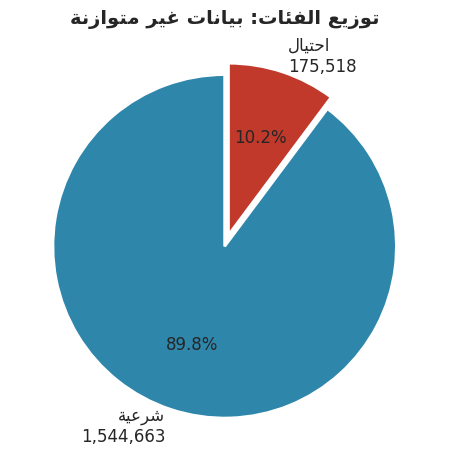

,شرعي,احتيال,نسبة الاحتيال %
transactionType,,,
DEBIT,5392,0,0.00
DEPOSIT,384431,0,0.00
PAYMENT,667245,0,0.00
TRANSFER,393810,175518,30.83
WITHDRAWAL,93785,0,0.00


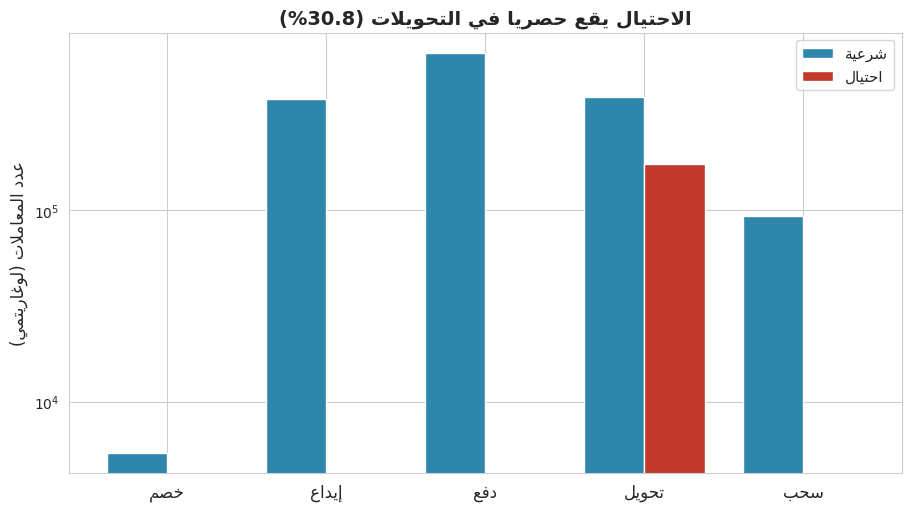

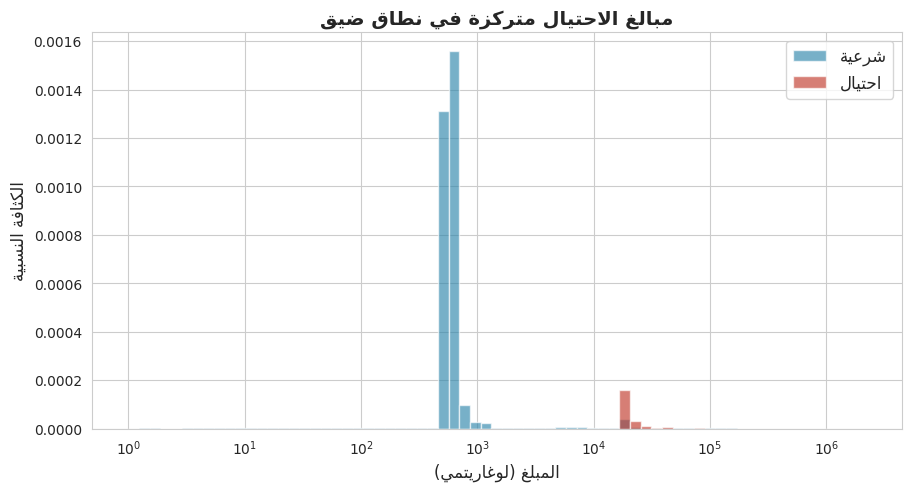

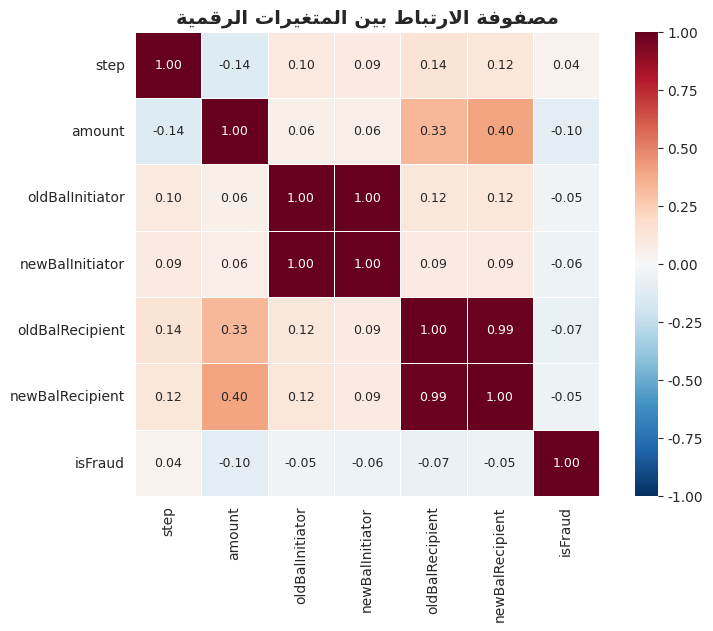

In [3]:
# ===== الاستكشاف: أربع رسوم =====
AR_TYPE = {"TRANSFER": "تحويل", "PAYMENT": "دفع", "DEPOSIT": "إيداع",
           "WITHDRAWAL": "سحب", "DEBIT": "خصم"}

# (1) توزيع الفئات
counts = df["isFraud"].value_counts()
n_legal, n_fraud = int(counts.get(0, 0)), int(counts.get(1, 0))
print(f"شرعية: {n_legal:,} ({n_legal/len(df)*100:.1f}%)  |  "
      f"احتيال: {n_fraud:,} ({n_fraud/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4.6), constrained_layout=True)
ax.pie([n_legal, n_fraud],
       labels=[ar(f"شرعية\n{n_legal:,}"), ar(f"احتيال\n{n_fraud:,}")],
       colors=[C_LEGAL, C_FRAUD], autopct="%.1f%%", startangle=90,
       explode=(0, 0.07), textprops={"fontsize": 12},
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title(ar("توزيع الفئات: بيانات غير متوازنة"), fontsize=14, fontweight="bold")
plt.show()

# (2) الاحتيال حسب نوع العملية
type_tbl = df.groupby("transactionType")["isFraud"].agg(شرعي=lambda s: (s == 0).sum(),
                                                        احتيال="sum")
type_tbl["نسبة الاحتيال %"] = (type_tbl["احتيال"] / type_tbl.sum(axis=1) * 100).round(2)
display(type_tbl)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
x = np.arange(len(type_tbl)); w = 0.38
ax.bar(x - w/2, type_tbl["شرعي"], width=w, color=C_LEGAL, label=ar("شرعية"))
ax.bar(x + w/2, type_tbl["احتيال"], width=w, color=C_FRAUD, label=ar("احتيال"))
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([ar(AR_TYPE[t]) for t in type_tbl.index], fontsize=12)
ax.set_ylabel(ar("عدد المعاملات (لوغاريتمي)"), fontsize=12)
ax.legend(fontsize=11)
ax.set_title(ar("الاحتيال يقع حصرياً في التحويلات (30.8%)"), fontsize=14, fontweight="bold")
plt.show()

# (3) توزيع المبالغ
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
bins = np.logspace(0, np.log10(df["amount"].max() + 1), 70)
ax.hist(df.loc[df["isFraud"] == 0, "amount"], bins=bins, density=True,
        color=C_LEGAL, alpha=0.65, label=ar("شرعية"))
ax.hist(df.loc[df["isFraud"] == 1, "amount"], bins=bins, density=True,
        color=C_FRAUD, alpha=0.65, label=ar("احتيال"))
ax.set_xscale("log")
ax.set_xlabel(ar("المبلغ (لوغاريتمي)"), fontsize=12)
ax.set_ylabel(ar("الكثافة النسبية"), fontsize=12)
ax.legend(fontsize=12)
ax.set_title(ar("مبالغ الاحتيال متركزة في نطاق ضيق"), fontsize=14, fontweight="bold")
plt.show()

# (4) مصفوفة الارتباط
num_cols = ["step", "amount", "oldBalInitiator", "newBalInitiator",
            "oldBalRecipient", "newBalRecipient", "isFraud"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8.2, 6.2), constrained_layout=True)
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={"size": 9})
ax.set_title(ar("مصفوفة الارتباط بين المتغيرات الرقمية"), fontsize=14, fontweight="bold")
plt.show()

## 3) المعالجة وهندسة الميزات

قرارات مستخلصة من الاستكشاف:

- **الجودة:** صفر قيم مفقودة وصفر مكرر — البيانات نظيفة، والكود يتضمن التنظيف الشرطي احتياطاً.
- **الأرصدة السالبة** (~44.6 ألف صف): ظاهرة حقيقية في المحاكاة، فنُبقيها مع **ميزة راية** لها بدل حذف صفوف بريئة.
- **التطبيع:** المبالغ والأرصدة شديدة الالتواء، فنطبق **تحويلاً لوغاريتمياً موقّعاً** يروّض الالتواء ويحافظ على إشارة السالب؛ ويتولى `StandardScaler` داخل النمذجة توحيد المقاييس.
- **ترميز One-Hot** لنوع العملية (5 أعمدة ثنائية).
- **ميزات سلوكية:** فجوة الرصيد (هل يستنزف المبلغ كامل رصيد المُرسل؟) وخطأ إثبات رصيد المستقبِل.

النتيجة: **16 ميزة** جاهزة للنمذجة.

In [4]:
# ===== هندسة الميزات: 16 ميزة =====
def signed_log(x):
    """لوغاريتم يحافظ على الإشارة (يتعامل مع الأرصدة السالبة)"""
    return np.sign(x) * np.log1p(np.abs(x))

fe = pd.DataFrame()
fe["step"] = df["step"].astype(np.float32)

# (1) لوغاريتم موقّع للمبالغ والأرصدة — ترويض الالتواء
for col in ["amount", "oldBalInitiator", "newBalInitiator",
            "oldBalRecipient", "newBalRecipient"]:
    fe[f"log_{col}"] = signed_log(df[col]).astype(np.float32)

# (2) ترميز نوع العملية One-Hot
for t in ["TRANSFER", "PAYMENT", "DEPOSIT", "WITHDRAWAL", "DEBIT"]:
    fe[f"is_{t.lower()}"] = (df["transactionType"] == t).astype(np.int8)

# (3) ميزات فجوة الرصيد: هل يستنزف المبلغ كامل رصيد المُرسل؟
fe["amount_minus_oldBal"] = (df["amount"] - df["oldBalInitiator"]).astype(np.float32)
fe["relative_gap"] = np.clip((df["amount"] - df["oldBalInitiator"])
                             / (df["amount"] + 1), -2, 2).astype(np.float32)

# (4) خطأ إثبات رصيد المستقبِل (الفرق بين المقيد والمرسل)
fe["dest_credit_error"] = ((df["newBalRecipient"] - df["oldBalRecipient"])
                           - df["amount"]).astype(np.float32)

# (5) رايات الأرصدة السالبة
fe["flag_negBalInitiator"] = (df["newBalInitiator"] < 0).astype(np.int8)
fe["flag_negBalRecipient"] = (df["newBalRecipient"] < 0).astype(np.int8)

# الهدف
fe["isFraud"] = df["isFraud"].astype(np.int8)

print(f"عدد الميزات: {fe.shape[1] - 1}")
print(f"شرعية: {(fe['isFraud']==0).sum():,} | احتيال: {(fe['isFraud']==1).sum():,}")
fe.head()

عدد الميزات: 16
شرعية: 1,544,663 | احتيال: 175,518


,step,log_amount,log_oldBalInitiator,log_newBalInitiator,log_oldBalRecipient,log_newBalRecipient,is_transfer,is_payment,is_deposit,is_withdrawal,is_debit,amount_minus_oldBal,relative_gap,dest_credit_error,flag_negBalInitiator,flag_negBalRecipient,isFraud
0,0.0,9.894748,12.142671,12.031054,2.231089,9.895166,1,0,0,0,0,-167887.218750,-2.000000,0.000000,0,0,1
1,0.0,6.396880,2.294553,2.294553,0.000000,0.000000,0,1,0,0,0,590.049988,0.983466,-598.969971,0,0,0
2,0.0,6.304174,4.549657,-6.116444,0.000000,6.304174,0,1,0,0,0,452.250000,0.827009,0.000000,1,0,0
3,0.0,9.895859,-6.116444,-9.918389,8.297225,10.079947,1,0,0,0,0,20299.259766,1.022735,0.010000,1,0,1
4,0.0,6.306075,11.977601,11.974158,0.000000,6.306075,0,1,0,0,0,-158601.875000,-2.000000,0.000000,0,0,0


## 4) النمذجة والتقييم

1. **تقسيم طبقي 80/20:** يحافظ على نسبة الاحتيال (10.2%) في جزأي التدريب والاختبار حتى لا يتشوه التقييم.
2. **خطا أساس للمقارنة العادلة:** نموذج ساذج (الكل شرعي) + قاعدة بسيطة مستخلصة من الاستكشاف (كل تحويل = احتيال) — أي نموذج لا يتفوق عليهما لا قيمة له.
3. **الانحدار اللوجستي** على كامل البيانات مع `class_weight='balanced'` لموازنة فئة الأقلية، و`StandardScaler` داخل pipeline لمنع تسرب معلومات الاختبار.
4. **خوارزمية الجيران الأقربين (KNN)** على عينة طبقية (150 ألف صف) لأنها تحسب المسافات لكل نقطة مقابل كل نقاط التدريب، مع اختيار k من {3, 7, 15} عبر مجموعة تحقق.
5. **التقييم** بالدقة والضبط والاستدعاء وF1 وAUC + مصفوفات الالتباس ومقارنة بصرية.

In [5]:
# ===== التقسيم + خطا الأساس + النموذجان =====
X = fe.drop(columns=["isFraud"]).astype(np.float64)  # float64: دقة عددية مطابقة للخط القياسي
y = fe["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"تدريب: {len(X_train):,} | اختبار: {len(X_test):,} "
      f"| نسبة الاحتيال في الاختبار: {y_test.mean()*100:.2f}%\n")

results = {}

def evaluate(name, y_true, y_pred, y_prob=None):
    """حساب المقاييس الأربعة + AUC وطباعتها"""
    res = {"accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
           "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
           "recall":    round(float(recall_score(y_true, y_pred)), 4),
           "f1":        round(float(f1_score(y_true, y_pred)), 4),
           "cm": confusion_matrix(y_true, y_pred).tolist()}
    if y_prob is not None:
        res["roc_auc"] = round(float(roc_auc_score(y_true, y_prob)), 4)
    results[name] = res
    print(f"[{name}] Acc={res['accuracy']*100:.2f}% | P={res['precision']*100:.2f}% | "
          f"R={res['recall']*100:.2f}% | F1={res['f1']*100:.2f}%"
          + (f" | AUC={res['roc_auc']:.4f}" if y_prob is not None else ""))

# (1) خط الأساس الأول: نموذج ساذج — يتوقع (شرعي) لكل معاملة
print("— خطا الأساس —")
evaluate("dumb_all_legal", y_test, np.zeros(len(y_test), dtype=int))

# (2) خط الأساس الثاني: قاعدة بسيطة — كل تحويل احتيال
evaluate("rule_every_transfer", y_test, X_test["is_transfer"].astype(int).values)

# (3) النموذج الأول: الانحدار اللوجستي على كامل البيانات
print("\n— النموذجان —")
lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, class_weight="balanced",
                      random_state=RANDOM_STATE))
lr.fit(X_train, y_train)
evaluate("logistic_regression", y_test, lr.predict(X_test),
         lr.predict_proba(X_test)[:, 1])

# (4) النموذج الثاني: KNN على عينة طبقية + اختيار k
_, sample = train_test_split(fe, test_size=KNN_SAMPLE,
                             stratify=fe["isFraud"], random_state=RANDOM_STATE)
Xs = sample.drop(columns=["isFraud"]).astype(np.float64)
ys = sample["isFraud"]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.20, stratify=ys, random_state=RANDOM_STATE)

Xk_tr, Xk_val, yk_tr, yk_val = train_test_split(
    Xs_tr, ys_tr, test_size=0.20, stratify=ys_tr, random_state=RANDOM_STATE)
sub = Xk_tr.sample(min(80_000, len(Xk_tr)), random_state=RANDOM_STATE)
k_scores = {}
for k in [3, 7, 15]:
    kt = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    kt.fit(sub, yk_tr.loc[sub.index])
    k_scores[k] = round(float(f1_score(yk_val, kt.predict(Xk_val))), 4)
    print(f"   اختيار k: k={k:>2} => F1 على التحقق = {k_scores[k]*100:.2f}%")
best_k = max(k_scores, key=k_scores.get)

knn = KNeighborsClassifier(n_neighbors=best_k, weights="distance", n_jobs=-1)
knn.fit(Xs_tr, ys_tr)
print(f"   أفضل k = {best_k}")
evaluate("knn", ys_te, knn.predict(Xs_te), knn.predict_proba(Xs_te)[:, 1])

تدريب: 1,376,144 | اختبار: 344,037 | نسبة الاحتيال في الاختبار: 10.20%

— خطا الأساس —
[dumb_all_legal] Acc=89.80% | P=0.00% | R=0.00% | F1=0.00%


[rule_every_transfer] Acc=77.07% | P=30.79% | R=100.00% | F1=47.09%

— النموذجان —


[logistic_regression] Acc=78.07% | P=31.75% | R=99.95% | F1=48.19% | AUC=0.8890


   اختيار k: k= 3 => F1 على التحقق = 15.48%


   اختيار k: k= 7 => F1 على التحقق = 11.68%


   اختيار k: k=15 => F1 على التحقق = 10.14%
   أفضل k = 3


[knn] Acc=85.73% | P=17.77% | R=10.98% | F1=13.57% | AUC=0.5804


,النموذج,الدقة,الضبط,الاستدعاء,F1,AUC
0,نموذج ساذج (الكل شرعي),89.80%,0.00%,0.00%,0.00%,—
1,قاعدة بسيطة (كل تحويل احتيال),77.07%,30.79%,100.00%,47.09%,—
2,الانحدار اللوجستي,78.07%,31.75%,99.95%,48.19%,0.889
3,"KNN (k=3, عينة 150 ألف)",85.73%,17.77%,10.98%,13.57%,0.580


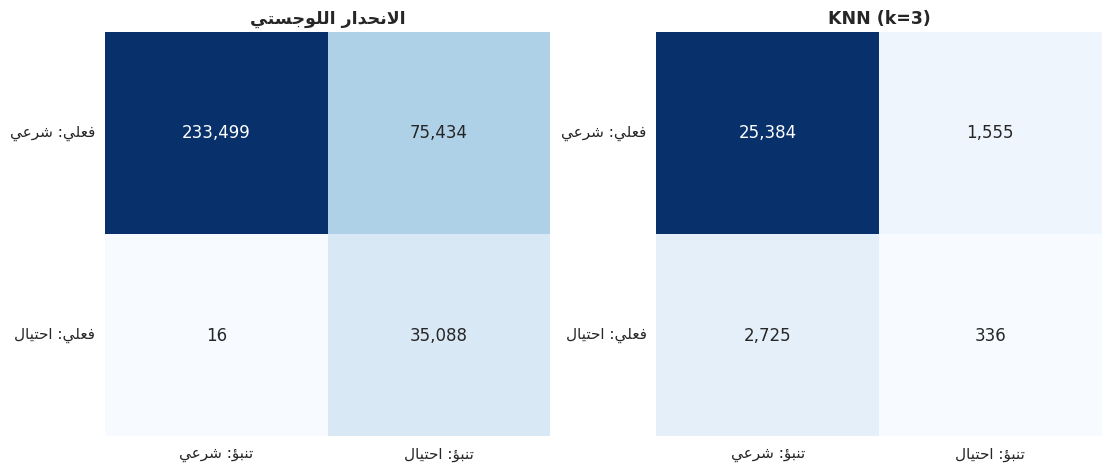

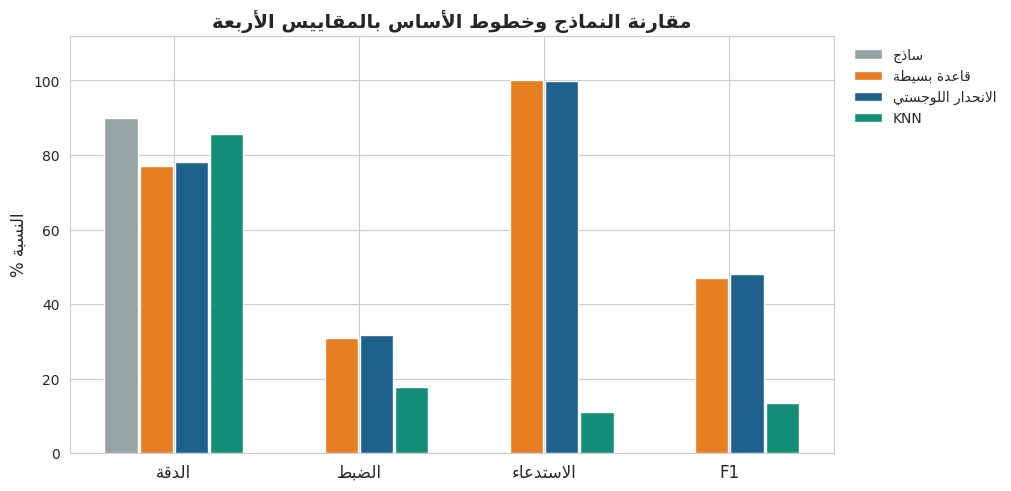

In [6]:
# ===== جدول النتائج + مصفوفات الالتباس + المقارنة =====
AR_NAMES = {"dumb_all_legal": "نموذج ساذج (الكل شرعي)",
            "rule_every_transfer": "قاعدة بسيطة (كل تحويل احتيال)",
            "logistic_regression": "الانحدار اللوجستي",
            "knn": f"KNN (k={best_k}, عينة 150 ألف)"}
rows = [{"النموذج": n,
         "الدقة": f"{results[k]['accuracy']*100:.2f}%",
         "الضبط": f"{results[k]['precision']*100:.2f}%",
         "الاستدعاء": f"{results[k]['recall']*100:.2f}%",
         "F1": f"{results[k]['f1']*100:.2f}%",
         "AUC": f"{results[k]['roc_auc']:.3f}" if "roc_auc" in results[k] else "—"}
        for k, n in AR_NAMES.items()]
display(pd.DataFrame(rows))

# مصفوفات الالتباس
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for ax_, key, title in [(axes[0], "logistic_regression", "الانحدار اللوجستي"),
                        (axes[1], "knn", f"KNN (k={best_k})")]:
    sns.heatmap(np.array(results[key]["cm"]), annot=True, fmt=",d",
                cmap="Blues", ax=ax_, cbar=False, annot_kws={"size": 12})
    ax_.set_xticklabels([ar("تنبؤ: شرعي"), ar("تنبؤ: احتيال")], fontsize=11)
    ax_.set_yticklabels([ar("فعلي: شرعي"), ar("فعلي: احتيال")], rotation=0, fontsize=11)
    ax_.set_title(ar(title), fontsize=12.5, fontweight="bold")
plt.show()

# مقارنة المقاييس الأربعة
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
metrics_lbl = [("accuracy", "الدقة"), ("precision", "الضبط"),
               ("recall", "الاستدعاء"), ("f1", "F1")]
models = [("dumb_all_legal", "ساذج", C_DUMB), ("rule_every_transfer", "قاعدة بسيطة", C_RULE),
          ("logistic_regression", "الانحدار اللوجستي", C_LR), ("knn", "KNN", C_KNN)]
x = np.arange(4)
for i, (key, label, color) in enumerate(models):
    vals = [results[key][m] * 100 for m, _ in metrics_lbl]
    ax.bar(x + (i - 1.5) * 0.19, vals, width=0.18, color=color, label=ar(label))
ax.set_xticks(x)
ax.set_xticklabels([ar(l) for _, l in metrics_lbl], fontsize=12)
ax.set_ylabel(ar("النسبة %"), fontsize=12)
ax.set_ylim(0, 112)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=10, frameon=False)
ax.set_title(ar("مقارنة النماذج وخطوط الأساس بالمقاييس الأربعة"),
             fontsize=14, fontweight="bold")
plt.show()

## 5) الخلاصة والاستنتاجات

| النموذج | الدقة | الضبط | الاستدعاء | F1 | AUC |
|---|---|---|---|---|---|
| نموذج ساذج (الكل شرعي) | **89.80%** | 0% | 0% | 0% | — |
| قاعدة بسيطة (كل تحويل احتيال) | 77.07% | 30.79% | 100% | 47.09% | — |
| **الانحدار اللوجستي** | 78.07% | **31.75%** | **99.95%** | **48.19%** | **0.889** |
| KNN (k=3) | 85.73% | 17.77% | 10.98% | 13.57% | 0.580 |

**خمسة استنتاجات:**

1. **فخ الدقة:** أعلى دقة في الجدول (89.80%) لنموذج عديم القيمة عملياً — يغتنم اختلال الفئات ولا يمسك بأي احتيال؛ فالمقياس العادل هنا هو الضبط والاستدعاء معاً.
2. **الانحدار اللوجستي هو الأفضل:** يتفوق على القاعدة البسيطة في المقاييس الأربعة جميعها ويكشف 99.95% من عمليات الاحتيال، ويخرج احتمالية قابلة للضبط وفق كلفة كل نوع من الأخطاء.
3. **ضعف KNN مفسَّر بنيوياً:** الإشارة الفعالة تكاد تكون أحادية البُعد (نوع العملية) بينما تُحسب المسافات عبر 16 بُعداً فتضيع الإشارة في الضجيج، يضاف إليه عدم توازن الفئات وكلفته الحسابية العالية.
4. **سقف الأداء من طبيعة البيانات:** الاحتيال داخل التحويلات موزع شبه عشوائي بخصائص الصفقة وحدها، لذا يبلغ النموذج حدّ القاعدة البسيطة المستخلصة من الاستكشاف.
5. **التطوير المستقبلي:** إغناء البيانات بخصائص سلوكية وشبكية (بصمة الجهاز، حدود السرعة، شبكة الحسابات)، وضبط عتبة الاحتمالية وفق كلفة الإنذار الخاطئ مقابل كلفة تسريب الاحتيال.